# Notebook 01 — Preprocess WISDM

**Purpose:** Parse, align, resample, window, normalize and save the WISDM dataset  
in the unified per-stream format required by all downstream notebooks.

**Input:**
```
/content/drive/MyDrive/wisdm-dataset/raw/phone/accel/data_1600_accel_phone.txt
/content/drive/MyDrive/wisdm-dataset/raw/phone/gyro/data_1600_gyro_phone.txt
/content/drive/MyDrive/wisdm-dataset/raw/watch/accel/data_1600_accel_watch.txt
/content/drive/MyDrive/wisdm-dataset/raw/watch/gyro/data_1600_gyro_watch.txt
```

**Output** (saved to `PROCESSED_PATHS['wisdm']/`):
```
phone_accel.npy       (N, 250, 3)
phone_gyro.npy        (N, 250, 3)
watch_accel.npy       (N, 250, 3)
watch_gyro.npy        (N, 250, 3)
y.npy                 (N,)  integer labels 0–17
subject_ids.npy       (N,)  subject IDs
stream_names.json     ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']
split_info.json       {train: [...], val: [...], test: [...]}
normalizers/          per-stream mean/std fitted on train subjects only
```

**Key decisions (from project plan):**
- Trailing semicolons stripped during parsing
- 4 streams processed independently — no concatenation
- Resampled 20Hz → 50Hz
- Sliding window: T=250, stride=125 (50% overlap)
- User-level split: 75% train / 12.5% val / 12.5% test
- Z-score normalisation fitted on train subjects only

---
**Run notebook 00 before this notebook.**

## Cell 1 — Setup

In [ ]:
# ─── Mount drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ─── Load config and all utilities from notebook 00 ───────────────────────────
# Update this path if you stored notebook 00 elsewhere
%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

print('\n✅ Setup complete — notebook 00 loaded')
print(f'   Dataset : WISDM')
print(f'   Output  : {PROCESSED_PATHS["wisdm"]}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subje

## Cell 2 — Parse Raw Files

WISDM format per line:
```
1600,A,252207666810782,-0.36476135,8.793503,1.0550842;
```
Fields: `subject_id, activity_label, timestamp_ns, x, y, z;`

The trailing `;` is a file-wide artifact — stripped on every line.

In [ ]:
# ─── WISDM Parsing Utilities ────────────────────────────────────────────────
import os
import glob
import pandas as pd
import numpy as np


def parse_wisdm_file(filepath: str) -> pd.DataFrame:
    """
    Parse one WISDM raw txt file into a clean DataFrame.
    """
    cfg          = DATASET_CONFIGS['wisdm']
    label_to_int = cfg['label_to_int']
    valid_labels = set(label_to_int.keys())

    records   = []
    n_dropped = 0

    with open(filepath, 'r') as f:
        for line_num, raw_line in enumerate(f, start=1):
            line = raw_line.strip().rstrip(';').strip()

            if not line:
                continue

            parts = line.split(',')

            if len(parts) != 6:
                n_dropped += 1
                continue

            try:
                subject_id = int(parts[0].strip())
                activity   = parts[1].strip()
                timestamp  = int(parts[2].strip())
                x          = float(parts[3].strip())
                y          = float(parts[4].strip())
                z          = float(parts[5].strip())
            except (ValueError, IndexError):
                n_dropped += 1
                continue

            if activity not in valid_labels:
                n_dropped += 1
                continue

            records.append({
                'subject_id': subject_id,
                'activity'  : activity,
                'label'     : label_to_int[activity],
                'timestamp' : timestamp,
                'x'         : np.float32(x),
                'y'         : np.float32(y),
                'z'         : np.float32(z),
            })

    df = pd.DataFrame(records)
    print(f'   Parsed {len(df):>8,} rows | dropped {n_dropped:>5,} | {os.path.basename(filepath)}')
    return df


# ─── NEW: Parse entire folder (ALL txt files) ────────────────────────────────
def parse_wisdm_folder(folder_path: str) -> pd.DataFrame:
    filepaths = sorted(glob.glob(os.path.join(folder_path, '*.txt')))

    if not filepaths:
        raise ValueError(f'No txt files found in {folder_path}')

    dfs = []
    print(f'\n📂 Found {len(filepaths)} files in {folder_path}\n')

    for fp in filepaths:
        df = parse_wisdm_file(fp)
        dfs.append(df)

    combined_df = pd.concat(dfs, ignore_index=True)

    print(f'✅ Combined → {len(combined_df):,} rows from {len(filepaths)} files\n')
    return combined_df


# ─── Parse ALL files (FIXED) ────────────────────────────────────────────────
print('Parsing WISDM raw files (ALL files)...')
paths = RAW_PATHS['wisdm']

raw = {
    'phone_accel': parse_wisdm_folder(paths['phone_accel']),
    'phone_gyro' : parse_wisdm_folder(paths['phone_gyro']),
    'watch_accel': parse_wisdm_folder(paths['watch_accel']),
    'watch_gyro' : parse_wisdm_folder(paths['watch_gyro']),
}


# ─── Quick sanity check ─────────────────────────────────────────────────────
print('\n── Quick check ──')
for name, df in raw.items():
    n_subj = df['subject_id'].nunique()
    n_act  = df['activity'].nunique()
    print(f'   {name:<15} → {len(df):>8,} rows | {n_subj} subjects | {n_act} activities')

Parsing WISDM raw files (ALL files)...

📂 Found 51 files in /content/drive/MyDrive/wisdm-dataset/raw/phone/accel/

   Parsed   64,311 rows | dropped     0 | data_1600_accel_phone.txt
   Parsed   81,457 rows | dropped     0 | data_1601_accel_phone.txt
   Parsed   84,890 rows | dropped     0 | data_1602_accel_phone.txt
   Parsed   81,841 rows | dropped     0 | data_1603_accel_phone.txt
   Parsed   64,314 rows | dropped     0 | data_1604_accel_phone.txt
   Parsed   81,281 rows | dropped     0 | data_1605_accel_phone.txt
   Parsed   64,315 rows | dropped     0 | data_1606_accel_phone.txt
   Parsed   76,702 rows | dropped     0 | data_1607_accel_phone.txt
   Parsed   96,523 rows | dropped     0 | data_1608_accel_phone.txt
   Parsed   61,330 rows | dropped     0 | data_1609_accel_phone.txt
   Parsed   80,870 rows | dropped     0 | data_1610_accel_phone.txt
   Parsed   64,314 rows | dropped     0 | data_1611_accel_phone.txt
   Parsed   64,312 rows | dropped     0 | data_1612_accel_phone.txt
 

## Cell 3 — Validate Subjects and Activities
Confirm all 4 streams have the same subjects and activities before alignment.

In [ ]:
print('Validating subjects and activities across all streams...')

# Collect subject and activity sets per stream
subj_sets = {name: set(df['subject_id'].unique()) for name, df in raw.items()}
act_sets  = {name: set(df['activity'].unique())   for name, df in raw.items()}

# Check intersection — subjects present in ALL streams
common_subjects = set.intersection(*subj_sets.values())
common_activities = set.intersection(*act_sets.values())

print(f'\n   Subjects in ALL streams : {len(common_subjects)}')
print(f'   Activities in ALL streams: {len(common_activities)}')

# Report any mismatches
for name in raw:
    only_in_this = subj_sets[name] - common_subjects
    missing_from_this = common_subjects - subj_sets[name]
    if only_in_this:
        print(f'   ⚠  {name}: subjects only in this stream: {only_in_this}')
    if missing_from_this:
        print(f'   ⚠  {name}: subjects MISSING from this stream: {missing_from_this}')

# Use only subjects and activities present in all 4 streams
VALID_SUBJECTS   = sorted(common_subjects)
VALID_ACTIVITIES = sorted(common_activities)

print(f'\n   Valid subjects   : {VALID_SUBJECTS}')
print(f'   Valid activities : {VALID_ACTIVITIES}')
print(f'\n✅ Validation done — using {len(VALID_SUBJECTS)} subjects × {len(VALID_ACTIVITIES)} activities')

Validating subjects and activities across all streams...

   Subjects in ALL streams : 51
   Activities in ALL streams: 18

   Valid subjects   : [np.int64(1600), np.int64(1601), np.int64(1602), np.int64(1603), np.int64(1604), np.int64(1605), np.int64(1606), np.int64(1607), np.int64(1608), np.int64(1609), np.int64(1610), np.int64(1611), np.int64(1612), np.int64(1613), np.int64(1614), np.int64(1615), np.int64(1616), np.int64(1617), np.int64(1618), np.int64(1619), np.int64(1620), np.int64(1621), np.int64(1622), np.int64(1623), np.int64(1624), np.int64(1625), np.int64(1626), np.int64(1627), np.int64(1628), np.int64(1629), np.int64(1630), np.int64(1631), np.int64(1632), np.int64(1633), np.int64(1634), np.int64(1635), np.int64(1636), np.int64(1637), np.int64(1638), np.int64(1639), np.int64(1640), np.int64(1641), np.int64(1642), np.int64(1643), np.int64(1644), np.int64(1645), np.int64(1646), np.int64(1647), np.int64(1648), np.int64(1649), np.int64(1650)]
   Valid activities : ['A', 'B', 'C',

## Cell 4 — Align Streams and Apply Sliding Window

**Alignment strategy:**
- Group each stream by (subject_id, activity)
- Sort each group by timestamp
- All 4 streams are at 20Hz and record the same sessions
- For each (subject, activity) pair, process all 4 streams together
  and apply the sliding window — this guarantees window indices align
  across streams

**Result:** For each window index `i`, the 4 arrays `phone_accel[i]`,  
`phone_gyro[i]`, `watch_accel[i]`, `watch_gyro[i]` correspond to the  
**same time window** of the **same subject** doing the **same activity**.

In [ ]:
cfg        = DATASET_CONFIGS['wisdm']
src_freq   = cfg['streams']['phone_accel']['freq']   # 20 Hz
stream_names = list(cfg['streams'].keys())           # ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']

# ─── Accumulators ─────────────────────────────────────────────────────────────
# {stream_name: list of (N_windows, 250, 3) arrays}
stream_windows : Dict[str, list] = {s: [] for s in stream_names}
all_labels     : list = []
all_subject_ids: list = []

# Track statistics
n_total_windows = 0
skipped_pairs   = []   # (subject, activity) pairs where streams had length mismatch

print('Aligning streams and applying sliding windows...')
print(f'Source freq: {src_freq}Hz → target: {TARGET_FREQ}Hz')
print(f'Window: {WINDOW_SIZE} samples | Stride: {WINDOW_STRIDE} samples')
print()

for subj in VALID_SUBJECTS:
    subj_windows_count = 0

    for act in VALID_ACTIVITIES:
        # Extract (timestamp, x, y, z) for each stream for this (subj, act)
        segments = {}
        for stream_name, df in raw.items():
            mask = (df['subject_id'] == subj) & (df['activity'] == act)
            seg  = df[mask].sort_values('timestamp')[['x','y','z']].values
            segments[stream_name] = seg.astype(np.float32)

        # Check all streams have data for this (subj, act)
        lengths = {k: len(v) for k, v in segments.items()}
        if any(l == 0 for l in lengths.values()):
            skipped_pairs.append((subj, act, 'missing_stream', lengths))
            continue

        # Resample all streams to TARGET_FREQ
        resampled = {}
        for stream_name, seg in segments.items():
            resampled[stream_name] = resample_stream(seg, src_freq=src_freq)

        # ✅ FIXED PART — always trim to shortest stream (no skipping)
        r_lengths = {k: len(v) for k, v in resampled.items()}
        min_len   = min(r_lengths.values())

        for stream_name in resampled:
            resampled[stream_name] = resampled[stream_name][:min_len]

        # Apply sliding window to all streams simultaneously
        # Use phone_accel as the reference to get window count
        ref_stream = resampled['phone_accel']
        label_int  = cfg['label_to_int'][act]

        ref_wins, labs, subs = sliding_window(
            ref_stream, label=label_int, subject_id=subj
        )

        if len(ref_wins) == 0:
            skipped_pairs.append((subj, act, 'too_short', r_lengths))
            continue

        n_wins = len(ref_wins)

        # Extract the same windows from all streams
        for stream_name in stream_names:
            arr = resampled[stream_name]
            starts = range(0, len(arr) - WINDOW_SIZE + 1, WINDOW_STRIDE)
            wins   = np.stack([arr[s:s + WINDOW_SIZE] for s in starts], axis=0)
            # Ensure window count matches reference (should always be equal)
            assert len(wins) == n_wins, (
                f'Window count mismatch for {stream_name}: {len(wins)} vs {n_wins}'
            )
            stream_windows[stream_name].append(wins)

        all_labels.extend(labs.tolist())
        all_subject_ids.extend(subs.tolist())
        subj_windows_count += n_wins
        n_total_windows    += n_wins

    print(f'   Subject {subj:>4} → {subj_windows_count:>5} windows')

print(f'\n   Total windows : {n_total_windows:,}')
print(f'   Skipped pairs : {len(skipped_pairs)}')
if skipped_pairs:
    for sp in skipped_pairs[:10]:
        print(f'     Skipped (subj={sp[0]}, act={sp[1]}, reason={sp[2]}): {sp[3]}')

Aligning streams and applying sliding windows...
Source freq: 20Hz → target: 50Hz
Window: 250 samples | Stride: 125 samples

   Subject 1600 →  1260 windows
   Subject 1601 →  1278 windows
   Subject 1602 →  1260 windows
   Subject 1603 →  1278 windows
   Subject 1604 →  1260 windows
   Subject 1605 →  1296 windows
   Subject 1606 →  1260 windows
   Subject 1607 →  1225 windows
   Subject 1608 →  1260 windows
   Subject 1609 →  1195 windows
   Subject 1610 →  1260 windows
   Subject 1611 →  1260 windows
   Subject 1612 →  1260 windows
   Subject 1613 →  1278 windows
   Subject 1614 →  1278 windows
   Subject 1615 →  1260 windows
   Subject 1616 →  1120 windows
   Subject 1617 →  1260 windows
   Subject 1618 →  1190 windows
   Subject 1619 →  1278 windows
   Subject 1620 →  1260 windows
   Subject 1621 →  1314 windows
   Subject 1622 →  1260 windows
   Subject 1623 →  1260 windows
   Subject 1624 →  1260 windows
   Subject 1625 →  1260 windows
   Subject 1626 →  1262 windows
   Subject 

Extra Step: Normalization

## Cell 5 — Stack into Final Arrays

In [ ]:
print('Stacking into final arrays...')

# Stack all windows per stream
final_streams : Dict[str, np.ndarray] = {}
for stream_name in stream_names:
    arr = np.concatenate(stream_windows[stream_name], axis=0).astype(np.float32)
    final_streams[stream_name] = arr
    print(f'   {stream_name:<15} → {arr.shape}')

final_y           = np.array(all_labels,      dtype=np.int64)
final_subject_ids = np.array(all_subject_ids, dtype=object)

print(f'   y              → {final_y.shape}  | classes: {np.unique(final_y)}')
print(f'   subject_ids    → {final_subject_ids.shape} | subjects: {np.unique(final_subject_ids)}')

# Sanity: all streams must have same N
ns = [v.shape[0] for v in final_streams.values()]
assert len(set(ns)) == 1, f'Stream lengths differ: {dict(zip(stream_names, ns))}'
assert ns[0] == len(final_y) == len(final_subject_ids), 'Length mismatch'

print(f'\n✅ Arrays consistent — N={ns[0]:,} windows across all streams')

Stacking into final arrays...
   phone_accel     → (64766, 250, 3)
   phone_gyro      → (64766, 250, 3)
   watch_accel     → (64766, 250, 3)
   watch_gyro      → (64766, 250, 3)
   y              → (64766,)  | classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
   subject_ids    → (64766,) | subjects: [1600 1601 1602 1603 1604 1605 1606 1607 1608 1609 1610 1611 1612 1613
 1614 1615 1616 1617 1618 1619 1620 1621 1622 1623 1624 1625 1626 1627
 1628 1629 1630 1631 1632 1633 1634 1635 1636 1637 1638 1639 1640 1641
 1642 1643 1644 1645 1646 1647 1648 1649 1650]

✅ Arrays consistent — N=64,766 windows across all streams


Extra step (normalization)

In [ ]:
import numpy as np

MAX_WINDOWS_PER_SUBJECT = 1300

print('\nNormalizing windows per subject...')

indices_to_keep = []

unique_subjects = np.unique(final_subject_ids)

for subj in unique_subjects:
    subj_indices = np.where(final_subject_ids == subj)[0]

    if len(subj_indices) > MAX_WINDOWS_PER_SUBJECT:
        # Randomly sample without replacement
        sampled = np.random.choice(subj_indices, MAX_WINDOWS_PER_SUBJECT, replace=False)
    else:
        sampled = subj_indices

    indices_to_keep.extend(sampled)

indices_to_keep = np.array(sorted(indices_to_keep))

# Apply to all streams
for stream_name in final_streams:
    final_streams[stream_name] = final_streams[stream_name][indices_to_keep]

# Apply to labels + subjects
final_y = final_y[indices_to_keep]
final_subject_ids = final_subject_ids[indices_to_keep]

print(f'✅ After normalization → {len(final_y):,} windows')

# Check distribution
print('\nPer-subject window counts after normalization:')
for subj in sorted(unique_subjects):
    count = np.sum(final_subject_ids == subj)
    print(f'   Subject {subj}: {count}')


Normalizing windows per subject...
✅ After normalization → 63,513 windows

Per-subject window counts after normalization:
   Subject 1600: 1260
   Subject 1601: 1278
   Subject 1602: 1260
   Subject 1603: 1278
   Subject 1604: 1260
   Subject 1605: 1296
   Subject 1606: 1260
   Subject 1607: 1225
   Subject 1608: 1260
   Subject 1609: 1195
   Subject 1610: 1260
   Subject 1611: 1260
   Subject 1612: 1260
   Subject 1613: 1278
   Subject 1614: 1278
   Subject 1615: 1260
   Subject 1616: 1120
   Subject 1617: 1260
   Subject 1618: 1190
   Subject 1619: 1278
   Subject 1620: 1260
   Subject 1621: 1300
   Subject 1622: 1260
   Subject 1623: 1260
   Subject 1624: 1260
   Subject 1625: 1260
   Subject 1626: 1262
   Subject 1627: 1260
   Subject 1628: 1260
   Subject 1629: 1300
   Subject 1630: 1260
   Subject 1631: 1260
   Subject 1632: 1260
   Subject 1633: 1260
   Subject 1634: 1260
   Subject 1635: 1260
   Subject 1636: 1260
   Subject 1637: 1120
   Subject 1638: 1121
   Subject 1639: 11

## Cell 6 — User-Level Train / Val / Test Split

In [ ]:
all_subjects = sorted(np.unique(final_subject_ids).tolist())
print(f'Splitting {len(all_subjects)} subjects into train/val/test...')

train_subjects, val_subjects, test_subjects = split_subjects(all_subjects)

split_info = {
    'train' : [int(s) for s in train_subjects],
    'val'   : [int(s) for s in val_subjects],
    'test'  : [int(s) for s in test_subjects],
}

# Count windows per split
for split_name, subjects in split_info.items():
    mask = get_split_mask(final_subject_ids, subjects)
    n_win = mask.sum()
    print(f'   {split_name:<6}: {len(subjects):>2} subjects | {n_win:>6,} windows')
    # Show class distribution
    classes, counts = np.unique(final_y[mask], return_counts=True)
    min_c, max_c = counts.min(), counts.max()
    print(f'           class count range: {min_c}–{max_c} windows per class')

print(f'\n✅ Split complete')
print(f'   Train subjects : {sorted(train_subjects)}')
print(f'   Val subjects   : {sorted(val_subjects)}')
print(f'   Test subjects  : {sorted(test_subjects)}')

Splitting 51 subjects into train/val/test...
   train : 38 subjects | 47,037 windows
           class count range: 2467–2696 windows per class
   val   :  6 subjects |  7,596 windows
           class count range: 422–422 windows per class
   test  :  7 subjects |  8,880 windows
           class count range: 493–499 windows per class

✅ Split complete
   Train subjects : [1603, 1604, 1605, 1606, 1607, 1609, 1610, 1611, 1615, 1616, 1617, 1618, 1620, 1621, 1623, 1624, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1634, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1650]
   Val subjects   : [1600, 1612, 1614, 1619, 1622, 1635]
   Test subjects  : [1601, 1602, 1608, 1613, 1633, 1636, 1649]


## Cell 7 — Per-Stream Normalisation
Fit z-score normaliser on TRAIN windows only.  
Apply to all splits.  
Save normaliser statistics for use during evaluation.

In [ ]:
normalizer_dir = os.path.join(PROCESSED_PATHS['wisdm'], 'normalizers')
os.makedirs(normalizer_dir, exist_ok=True)

train_mask = get_split_mask(final_subject_ids, train_subjects)

print('Fitting and applying per-stream normalisers (train subjects only)...')
normalized_streams : Dict[str, np.ndarray] = {}
normalizers        : Dict[str, StreamNormalizer] = {}

for stream_name, arr in final_streams.items():
    norm = StreamNormalizer()

    # Fit on training windows only
    norm.fit(arr[train_mask])

    # Apply to all windows
    arr_norm = norm.transform(arr)
    normalized_streams[stream_name] = arr_norm
    normalizers[stream_name]        = norm

    # Save normaliser statistics
    norm_path = os.path.join(normalizer_dir, stream_name)
    norm.save(norm_path)

    # Verify on train set
    train_mean = arr_norm[train_mask].mean()
    train_std  = arr_norm[train_mask].std()
    print(f'   {stream_name:<15} → train mean={train_mean:.4f} | train std={train_std:.4f}')

print(f'\n✅ Normalisation done — savers stored in {normalizer_dir}')

Fitting and applying per-stream normalisers (train subjects only)...
   phone_accel     → train mean=-0.0008 | train std=1.0085
   phone_gyro      → train mean=0.0000 | train std=1.0056
   watch_accel     → train mean=-0.0019 | train std=1.0088
   watch_gyro      → train mean=0.0000 | train std=1.0082

✅ Normalisation done — savers stored in /content/drive/MyDrive/fsl_har_processed/wisdm/normalizers


## Cell 8 — Save Processed Dataset

In [ ]:
print('Saving processed WISDM dataset...')

save_processed_dataset(
    dataset_name  = 'wisdm',
    stream_arrays = normalized_streams,
    y             = final_y,
    subject_ids   = final_subject_ids,
    stream_names  = stream_names,
    split_info    = split_info,
)

Saving processed WISDM dataset...
   Saved stream phone_accel               → (63513, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/wisdm/phone_accel.npy
   Saved stream phone_gyro                → (63513, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/wisdm/phone_gyro.npy
   Saved stream watch_accel               → (63513, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/wisdm/watch_accel.npy
   Saved stream watch_gyro                → (63513, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/wisdm/watch_gyro.npy
   Saved y.npy          → (63513,)
   Saved subject_ids    → (63513,)
   Saved split_info.json

✅ Dataset "wisdm" saved to /content/drive/MyDrive/fsl_har_processed/wisdm


## Cell 9 — Verification: Load and Sanity Check
Load what was just saved and confirm everything is consistent.

In [ ]:
print('Verifying saved dataset by reloading from disk...\n')

loaded = load_processed_dataset('wisdm')

print('\n── Shapes ──')
for name, arr in loaded['streams'].items():
    print(f'   {name:<15} : {arr.shape}  dtype={arr.dtype}')

print(f'   y              : {loaded["y"].shape}  dtype={loaded["y"].dtype}')
print(f'   subject_ids    : {loaded["subject_ids"].shape}')

print('\n── Label distribution ──')
cfg = DATASET_CONFIGS['wisdm']
label_names = {v: k for k, v in cfg['label_to_int'].items()}
for label_int in sorted(np.unique(loaded['y'])):
    count      = (loaded['y'] == label_int).sum()
    act_letter = label_names[label_int]
    act_name   = cfg['activity_labels'][act_letter]
    print(f'   [{label_int:>2}] {act_name:<15} ({act_letter}) : {count:>6,} windows')

print('\n── Split info ──')
for split_name, subjs in loaded['split_info'].items():
    print(f'   {split_name:<6}: {subjs}')

print('\n── Consistency checks ──')
stream_ns = [v.shape[0] for v in loaded['streams'].values()]
assert len(set(stream_ns)) == 1, f'Stream N mismatch: {stream_ns}'
assert stream_ns[0] == len(loaded['y']), 'y length mismatch'
assert stream_ns[0] == len(loaded['subject_ids']), 'subject_ids length mismatch'
assert all(arr.shape[1] == WINDOW_SIZE for arr in loaded['streams'].values()), 'Wrong window size'
assert all(arr.shape[2] == 3 for arr in loaded['streams'].values()), 'Wrong n_axes'
assert set(loaded['y']).issubset(set(range(18))), 'Unknown label found'
print('   ✅ All consistency checks passed')

Verifying saved dataset by reloading from disk...

✅ Loaded "wisdm" — 63513 windows | 4 streams

── Shapes ──
   phone_accel     : (63513, 250, 3)  dtype=float32
   phone_gyro      : (63513, 250, 3)  dtype=float32
   watch_accel     : (63513, 250, 3)  dtype=float32
   watch_gyro      : (63513, 250, 3)  dtype=float32
   y              : (63513,)  dtype=int64
   subject_ids    : (63513,)

── Label distribution ──
   [ 0] walking         (A) :  3,611 windows
   [ 1] jogging         (B) :  3,459 windows
   [ 2] stairs          (C) :  3,382 windows
   [ 3] sitting         (D) :  3,582 windows
   [ 4] standing        (E) :  3,533 windows
   [ 5] typing          (F) :  3,443 windows
   [ 6] teeth           (G) :  3,584 windows
   [ 7] soup            (H) :  3,536 windows
   [ 8] chips           (I) :  3,533 windows
   [ 9] pasta           (J) :  3,441 windows
   [10] drinking        (K) :  3,603 windows
   [11] sandwich        (L) :  3,479 windows
   [12] kicking         (M) :  3,587 windows


## Cell 10 — Verification Plots
Visual checks to confirm preprocessing is sensible.

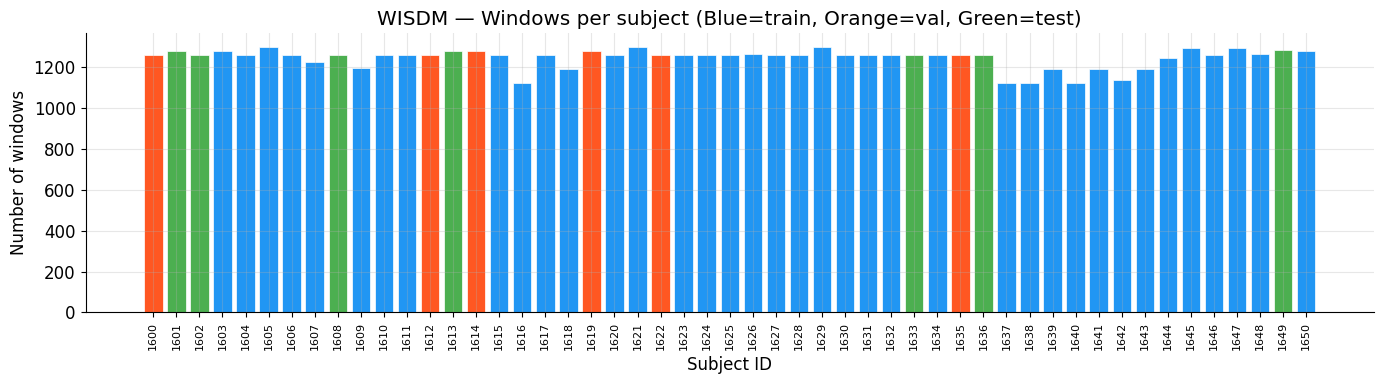

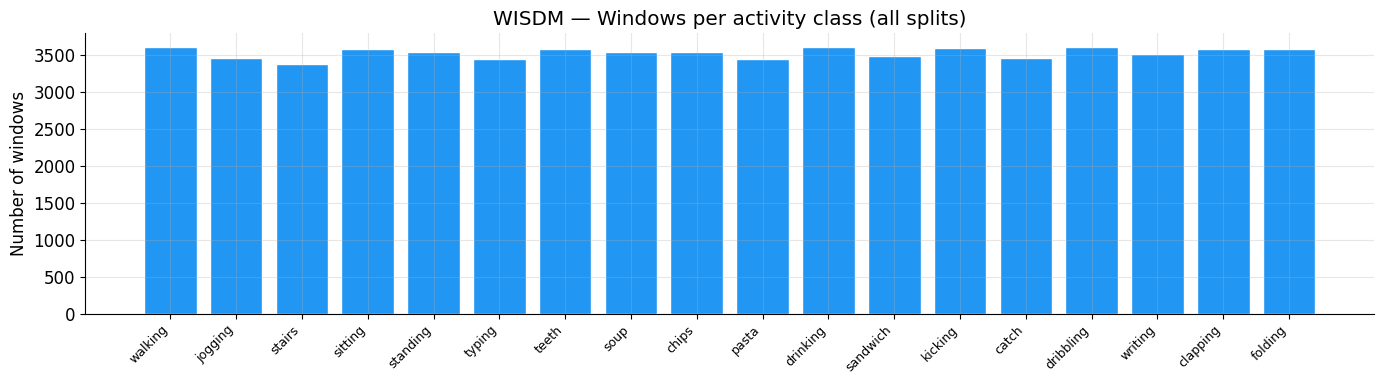

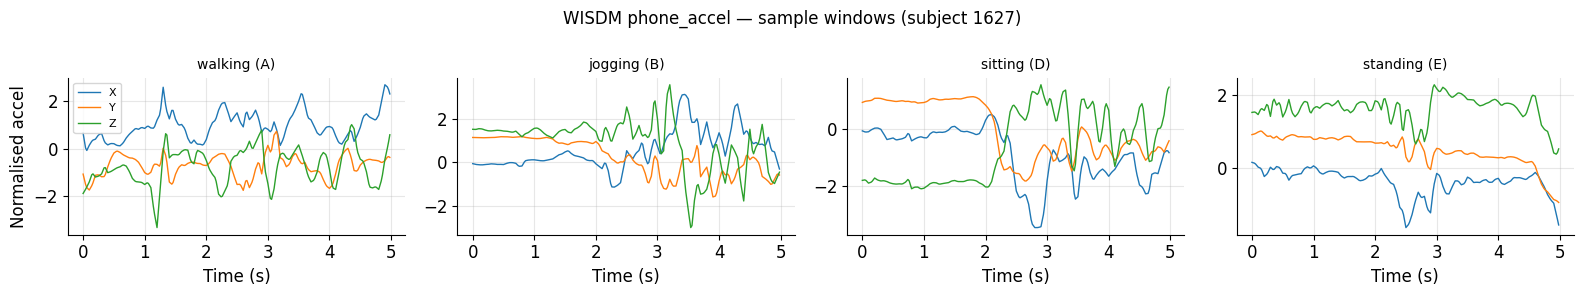

In [ ]:
# ─── Plot 1: Windows per subject ──────────────────────────────────────────────
subj_ids_loaded = loaded['subject_ids']
subjects_sorted = sorted(np.unique(subj_ids_loaded))
win_counts      = [(subj_ids_loaded == s).sum() for s in subjects_sorted]

fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['#2196F3' if s in split_info['train']
            else '#FF5722' if s in split_info['val']
            else '#4CAF50'
            for s in subjects_sorted]
bars = ax.bar(range(len(subjects_sorted)), win_counts, color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(subjects_sorted)))
ax.set_xticklabels(subjects_sorted, rotation=90, fontsize=8)
ax.set_xlabel('Subject ID')
ax.set_ylabel('Number of windows')
ax.set_title('WISDM — Windows per subject (Blue=train, Orange=val, Green=test)')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['wisdm'], 'plot_windows_per_subject.png'), dpi=120)
plt.show()

# ─── Plot 2: Class distribution ───────────────────────────────────────────────
y_loaded    = loaded['y']
act_names   = [cfg['activity_labels'][label_names[i]] for i in range(18)]
class_counts= [(y_loaded == i).sum() for i in range(18)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(18), class_counts, color='#2196F3', edgecolor='white')
ax.set_xticks(range(18))
ax.set_xticklabels(act_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of windows')
ax.set_title('WISDM — Windows per activity class (all splits)')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['wisdm'], 'plot_class_distribution.png'), dpi=120)
plt.show()

# ─── Plot 3: Sample windows from one subject ──────────────────────────────────
# Show one window from 4 different activities for phone_accel
sample_stream = loaded['streams']['phone_accel']
sample_subj   = train_subjects[0]
subj_mask     = (loaded['subject_ids'] == sample_subj)
sample_acts   = [0, 1, 3, 4]   # walking, jogging, sitting, standing
act_name_map  = cfg['activity_labels']
label_to_letter = {v: k for k, v in cfg['label_to_int'].items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, act_id in zip(axes, sample_acts):
    act_mask = subj_mask & (loaded['y'] == act_id)
    if act_mask.sum() == 0:
        ax.set_title(f'No data for act {act_id}')
        continue
    win = sample_stream[act_mask][0]   # first window
    t   = np.arange(WINDOW_SIZE) / TARGET_FREQ
    ax.plot(t, win[:, 0], label='X', linewidth=1)
    ax.plot(t, win[:, 1], label='Y', linewidth=1)
    ax.plot(t, win[:, 2], label='Z', linewidth=1)
    letter  = label_to_letter[act_id]
    ax.set_title(f'{act_name_map[letter]} ({letter})', fontsize=10)
    ax.set_xlabel('Time (s)')
    if ax == axes[0]:
        ax.set_ylabel('Normalised accel')
        ax.legend(fontsize=8)

fig.suptitle(f'WISDM phone_accel — sample windows (subject {sample_subj})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['wisdm'], 'plot_sample_windows.png'), dpi=120)
plt.show()

## Cell 11 — Final Summary

In [ ]:
N = loaded['y'].shape[0]

print('=' * 60)
print('  WISDM PREPROCESSING COMPLETE')
print('=' * 60)
print(f'  Total windows      : {N:,}')
print(f'  Streams            : {stream_names}')
print(f'  Window shape       : ({WINDOW_SIZE}, 3) @ {TARGET_FREQ}Hz')
print(f'  Classes            : {len(np.unique(loaded["y"]))} activities')
print(f'  Subjects           : {len(all_subjects)}')
print(f'    Train            : {len(train_subjects)} subjects')
print(f'    Val              : {len(val_subjects)} subjects')
print(f'    Test             : {len(test_subjects)} subjects')
print(f'  Saved to           : {PROCESSED_PATHS["wisdm"]}')
print('=' * 60)
print()
print('  Files saved:')
for fname in sorted(os.listdir(PROCESSED_PATHS['wisdm'])):
    fpath = os.path.join(PROCESSED_PATHS['wisdm'], fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'    {fname:<35} {size_mb:.2f} MB')
print()
print('  ✅ Ready for notebook 05 (CNN backbone training)')
print('     or run notebooks 02–04 first to preprocess other datasets')
print('=' * 60)

  WISDM PREPROCESSING COMPLETE
  Total windows      : 64,766
  Streams            : ['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro']
  Window shape       : (250, 3) @ 50Hz
  Classes            : 18 activities
  Subjects           : 51
    Train            : 38 subjects
    Val              : 6 subjects
    Test             : 7 subjects
  Saved to           : /content/drive/MyDrive/fsl_har_processed/wisdm

  Files saved:
    phone_accel.npy                     194.30 MB
    phone_gyro.npy                      194.30 MB
    plot_class_distribution.png         0.06 MB
    plot_sample_windows.png             0.14 MB
    plot_windows_per_subject.png        0.05 MB
    split_info.json                     0.00 MB
    stream_names.json                   0.00 MB
    subject_ids.npy                     0.19 MB
    watch_accel.npy                     194.30 MB
    watch_gyro.npy                      194.30 MB
    y.npy                               0.52 MB

  ✅ Ready for notebook 05 (CN